In [1]:
# Cell 1 - Imports and load data
import pandas as pd
import numpy as np
import shap
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('/content/bq-results-20260323-203006-1774297820102.csv')
print(f"Shape: {df.shape}")


Shape: (406031, 53)


In [2]:
# Cell 2 - Preprocessing
df['marital_status'] = df['marital_status'].fillna('UNKNOWN')
df['language'] = df['language'].fillna('UNKNOWN')
df['insurance'] = df['insurance'].fillna('UNKNOWN')
df['admission_location'] = df['admission_location'].fillna('UNKNOWN')
df['discharge_location'] = df['discharge_location'].fillna('UNKNOWN')
df['race'] = df['race'].fillna('UNKNOWN')

lab_cols = ['num_lab_tests_24h', 'num_abnormal_labs', 'hemoglobin_min',
            'wbc_max', 'creatinine_max', 'sodium_min', 'sodium_max',
            'potassium_min', 'potassium_max', 'glucose_min', 'glucose_max']
for col in lab_cols:
    df[col] = df[col].fillna(df[col].median())

hist_cols = ['days_since_last_discharge', 'num_admissions_last_30d',
             'num_admissions_last_90d', 'num_admissions_last_year',
             'total_prior_admissions', 'recent_admission_flag',
             'frequent_flyer_flag']
for col in hist_cols:
    df[col] = df[col].fillna(0)

df = df.fillna(df.median(numeric_only=True))

categorical_cols = ['gender', 'race', 'marital_status', 'language', 'insurance',
                    'admission_location', 'discharge_location', 'admission_type']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

import pickle
feature_cols  = pickle.load(open('/content/final_feature_cols.pkl', 'rb'))
split         = pickle.load(open('/content/final_split_indices.pkl', 'rb'))
train_end     = split['train_end']
val_end       = split['val_end']

df['admittime'] = pd.to_datetime(df['admittime'])
df_sorted = df.sort_values('admittime').reset_index(drop=True)

X = df_sorted[feature_cols]
y = df_sorted['readmitted_30d']

X_train, y_train = X.iloc[:train_end],        y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],          y.iloc[val_end:]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Features: {len(feature_cols)}")

Train: 284,221 | Val: 60,905 | Test: 60,905
Features: 45


In [3]:
# Cell 2.5 - Retrain XGBoost with best params and current features
import pickle

xgb_model = pickle.load(open('/content/xgboost_final_45f.pkl', 'rb'))

y_pred = xgb_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score
auroc = roc_auc_score(y_test, y_pred)
print(f"XGBoost final model loaded. Test AUROC: {auroc:.4f}")
print(f"Features: {xgb_model.n_features_in_}")

XGBoost final model loaded. Test AUROC: 0.7183
Features: 45


In [4]:
# Cell 3 - SHAP TreeExplainer
import shap

# Sample 2000 from test set for SHAP analysis
X_shap = X_test.sample(2000, random_state=42)

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")
print("SHAP computation complete.")

Computing SHAP values...
SHAP values shape: (2000, 45)
Expected value (base rate): 0.0104
SHAP computation complete.


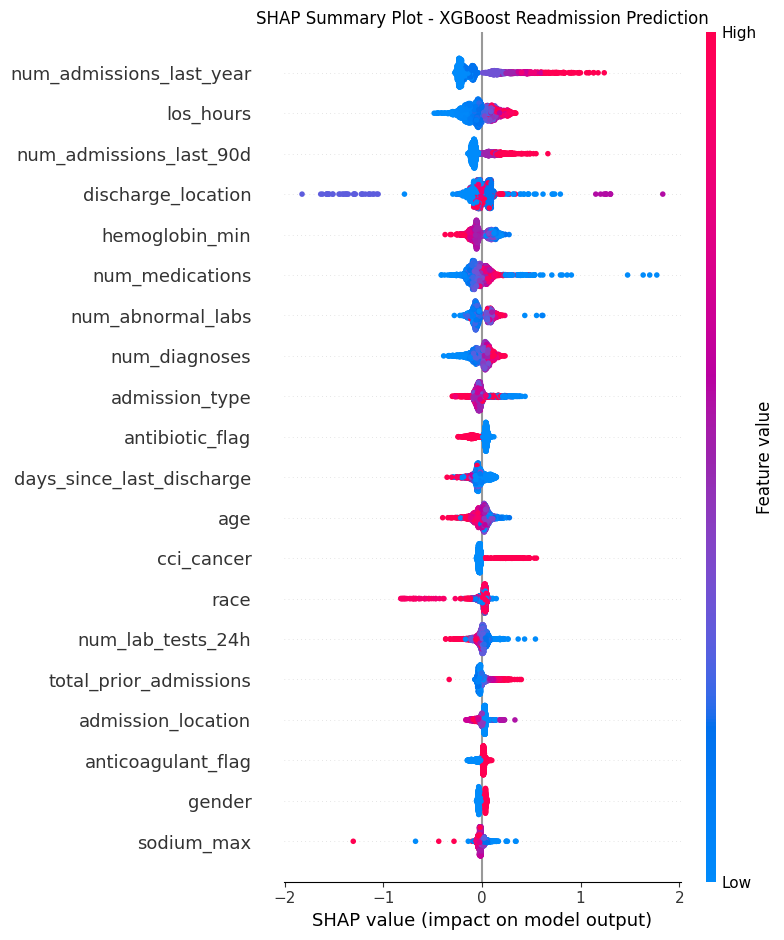

Saved: shap_summary_plot.png


In [5]:
# Cell 4 - SHAP Summary Plot (Beeswarm)
import matplotlib.pyplot as plt
shap.initjs()

plt.figure()
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary Plot - XGBoost Readmission Prediction")
plt.tight_layout()
plt.savefig('/content/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_plot.png")

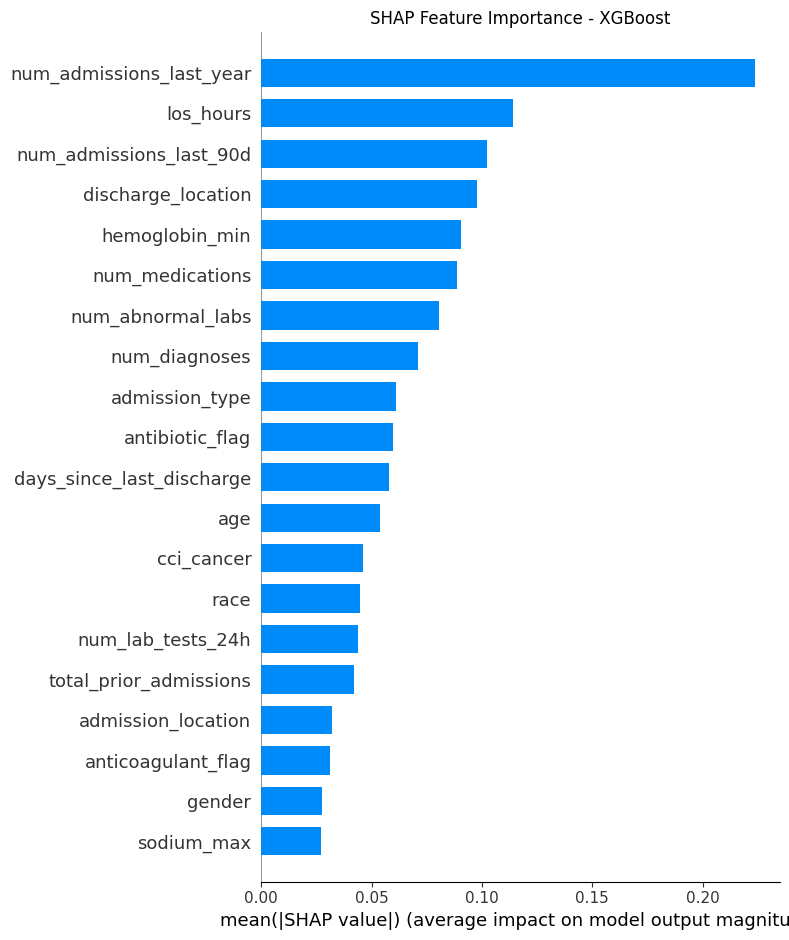

Saved: shap_bar_plot.png


In [6]:
# Cell 5 - SHAP Bar Plot (Mean Absolute Importance)
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - XGBoost")
plt.tight_layout()
plt.savefig('/content/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_plot.png")

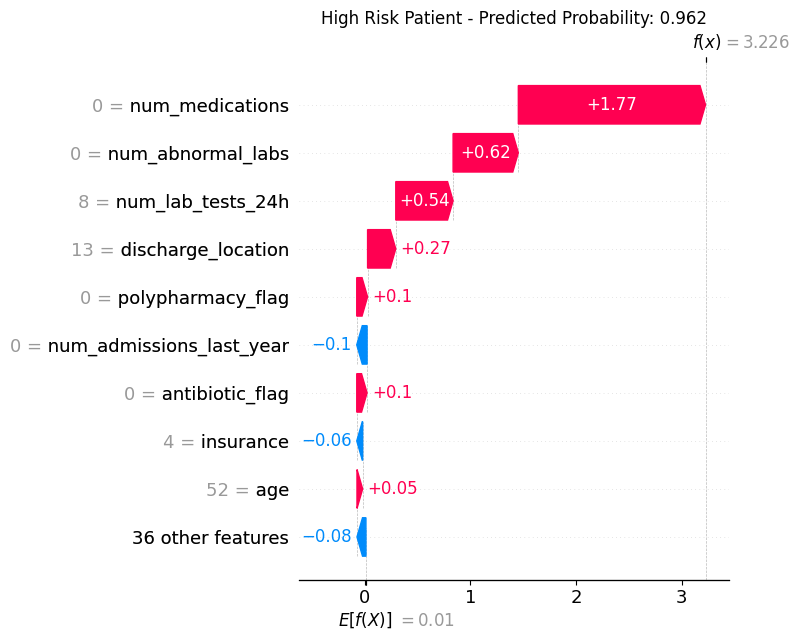

High risk patient predicted probability: 0.9618


In [7]:
# Cell 6 - Waterfall plot - High risk patient
import shap

# Get predicted probabilities for shap sample
y_pred_shap = xgb_model.predict_proba(X_shap)[:, 1]

# Find highest risk patient
high_risk_idx = y_pred_shap.argmax()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[high_risk_idx],
        feature_names=feature_cols
    ),
    show=False
)
plt.title(f"High Risk Patient - Predicted Probability: {y_pred_shap[high_risk_idx]:.3f}")
plt.tight_layout()
plt.savefig('/content/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"High risk patient predicted probability: {y_pred_shap[high_risk_idx]:.4f}")

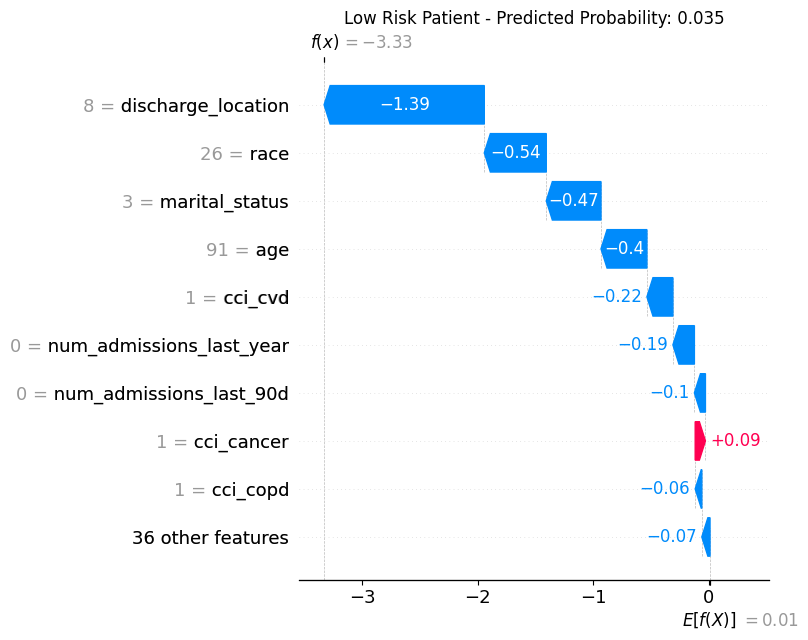

Low risk patient predicted probability: 0.0346


In [8]:
# Cell 7 - Waterfall plot - Low risk patient
low_risk_idx = y_pred_shap.argmin()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[low_risk_idx],
        feature_names=feature_cols
    ),
    show=False
)
plt.title(f"Low Risk Patient - Predicted Probability: {y_pred_shap[low_risk_idx]:.3f}")
plt.tight_layout()
plt.savefig('/content/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Low risk patient predicted probability: {y_pred_shap[low_risk_idx]:.4f}")

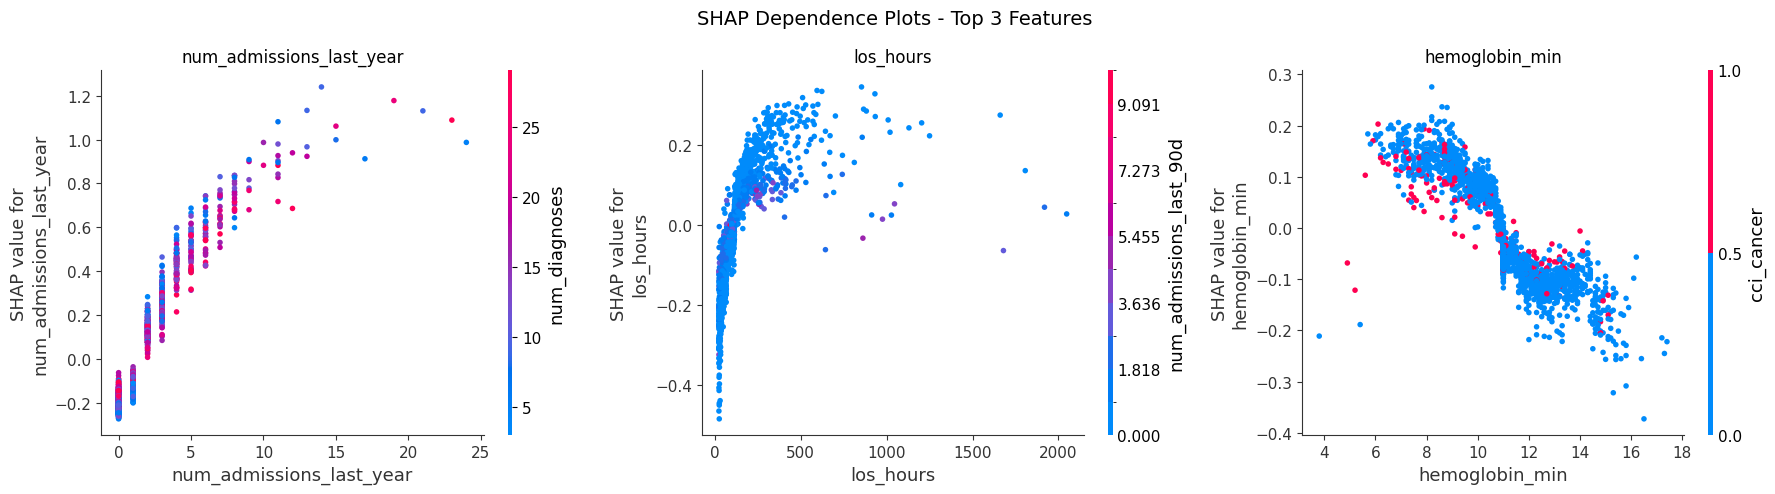

Saved: shap_dependence_plots.png


In [9]:
# Cell 8 - Dependence plots for top 3 features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 - num_admissions_last_year
shap.dependence_plot(
    "num_admissions_last_year",
    shap_values,
    X_shap,
    ax=axes[0],
    show=False
)
axes[0].set_title("num_admissions_last_year")

# Plot 2 - los_hours
shap.dependence_plot(
    "los_hours",
    shap_values,
    X_shap,
    ax=axes[1],
    show=False
)
axes[1].set_title("los_hours")

# Plot 3 - hemoglobin_min
shap.dependence_plot(
    "hemoglobin_min",
    shap_values,
    X_shap,
    ax=axes[2],
    show=False
)
axes[2].set_title("hemoglobin_min")

plt.suptitle("SHAP Dependence Plots - Top 3 Features", fontsize=14)
plt.tight_layout()
plt.savefig('/content/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_plots.png")

In [10]:
# Cell 9 - SHAP Interaction Values
X_shap_small = X_shap.sample(1000, random_state=42)

print("Computing interaction values...")
shap_interaction_values = explainer.shap_interaction_values(X_shap_small)

print(f"Shape: {shap_interaction_values.shape}")
print("Complete.")

Computing interaction values...
Shape: (1000, 45, 45)
Complete.


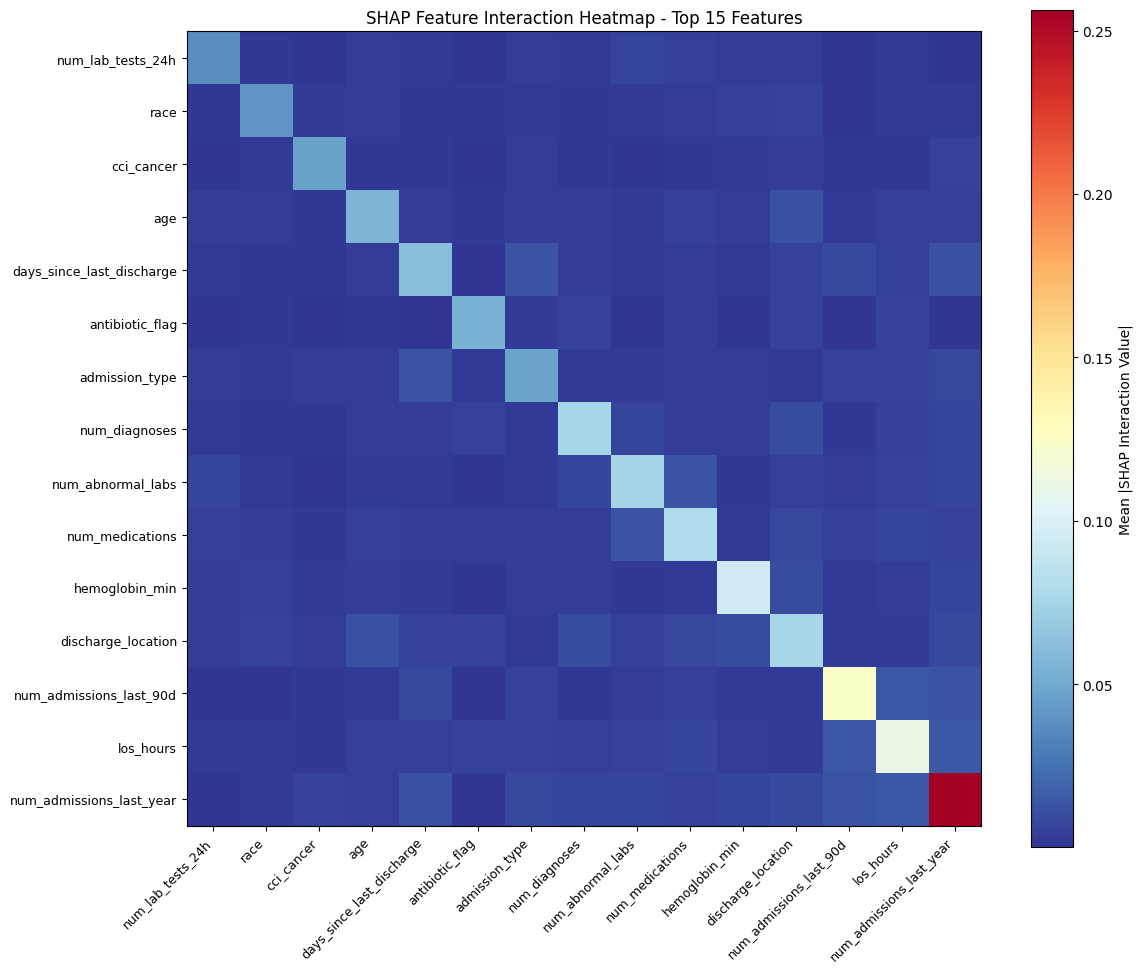

Saved: shap_interaction_heatmap.png


In [11]:
# Cell 10 - Interaction values heatmap
import numpy as np

# Mean absolute interaction values across all patients
mean_interactions = np.abs(shap_interaction_values).mean(axis=0)

# Plot top 15 features interaction matrix
top_features_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-15:]
top_feature_names = [feature_cols[i] for i in top_features_idx]
interaction_matrix = mean_interactions[np.ix_(top_features_idx, top_features_idx)]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(interaction_matrix, cmap='RdYlBu_r')
ax.set_xticks(range(len(top_feature_names)))
ax.set_yticks(range(len(top_feature_names)))
ax.set_xticklabels(top_feature_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top_feature_names, fontsize=9)
plt.colorbar(im, ax=ax, label='Mean |SHAP Interaction Value|')
ax.set_title('SHAP Feature Interaction Heatmap - Top 15 Features')
plt.tight_layout()
plt.savefig('/content/shap_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_interaction_heatmap.png")

In [13]:
# Cell 11 - Subgroup Analysis
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

le_mappings = pickle.load(open('/content/final_le_mappings.pkl', 'rb'))

subgroup_results = {}

# Race subgroups
race_map = le_mappings['race']['int_to_label']
for race_int, race_label in race_map.items():
    mask = X_test['race'] == race_int
    if mask.sum() >= 20:
        y_true_sub = y_test[mask]
        y_pred_sub = xgb_model.predict_proba(X_test[mask])[:, 1]
        if y_true_sub.nunique() == 2:
            auroc = roc_auc_score(y_true_sub, y_pred_sub)
            subgroup_results[race_label] = {
                'auroc': auroc,
                'n': int(mask.sum()),
                'readmission_rate': float(y_true_sub.mean())
            }

print("Race Subgroup AUROC Results:")
print(f"{'Group':<45} {'N':>8} {'Readm%':>8} {'AUROC':>8}")
print("-" * 72)
for label, vals in sorted(subgroup_results.items(), key=lambda x: x[1]['auroc'], reverse=True):
    print(f"{label:<45} {vals['n']:>8,} {vals['readmission_rate']*100:>7.1f}% {vals['auroc']:>8.4f}")

# Gender subgroups
print("\nGender Subgroup AUROC Results:")
gender_map = le_mappings['gender']['int_to_label']
print(f"Encoding: {le_mappings['gender']['int_to_label']}")
for g_int, g_label in gender_map.items():
    mask = X_test['gender'] == g_int
    if mask.sum() >= 20:
        y_true_sub = y_test[mask]
        y_pred_sub = xgb_model.predict_proba(X_test[mask])[:, 1]
        if y_true_sub.nunique() == 2:
            auroc = roc_auc_score(y_true_sub, y_pred_sub)
            print(f"  {g_label} (encoded {g_int}): N={mask.sum():,}, AUROC={auroc:.4f}")

# Age subgroups
print("\nAge Subgroup AUROC Results:")
age_bins   = [0, 45, 65, 80, 200]
age_labels = ['<45', '45-64', '65-79', '80+']
X_test_age = X_test.copy()
X_test_age['age_group'] = pd.cut(X_test_age['age'], bins=age_bins, labels=age_labels)
for grp in age_labels:
    mask = X_test_age['age_group'] == grp
    if mask.sum() >= 20:
        y_true_sub = y_test[mask]
        y_pred_sub = xgb_model.predict_proba(X_test[mask])[:, 1]
        if y_true_sub.nunique() == 2:
            auroc = roc_auc_score(y_true_sub, y_pred_sub)
            print(f"  {grp}: N={mask.sum():,}, readmission rate={y_true_sub.mean()*100:.1f}%, AUROC={auroc:.4f}")

Race Subgroup AUROC Results:
Group                                                N   Readm%    AUROC
------------------------------------------------------------------------
HISPANIC/LATINO - MEXICAN                           62    14.5%   0.8616
HISPANIC/LATINO - HONDURAN                          77    20.8%   0.8422
UNKNOWN                                          1,016     5.0%   0.8311
HISPANIC/LATINO - CUBAN                             72    33.3%   0.7960
ASIAN - ASIAN INDIAN                               159    20.1%   0.7881
PORTUGUESE                                         228    30.3%   0.7852
UNABLE TO OBTAIN                                   265     5.3%   0.7803
ASIAN                                              707    13.7%   0.7538
HISPANIC/LATINO - COLUMBIAN                         95    15.8%   0.7500
BLACK/CARIBBEAN ISLAND                             520    21.5%   0.7381
WHITE - OTHER EUROPEAN                           1,813    18.8%   0.7362
HISPANIC/LATINO - DOMI

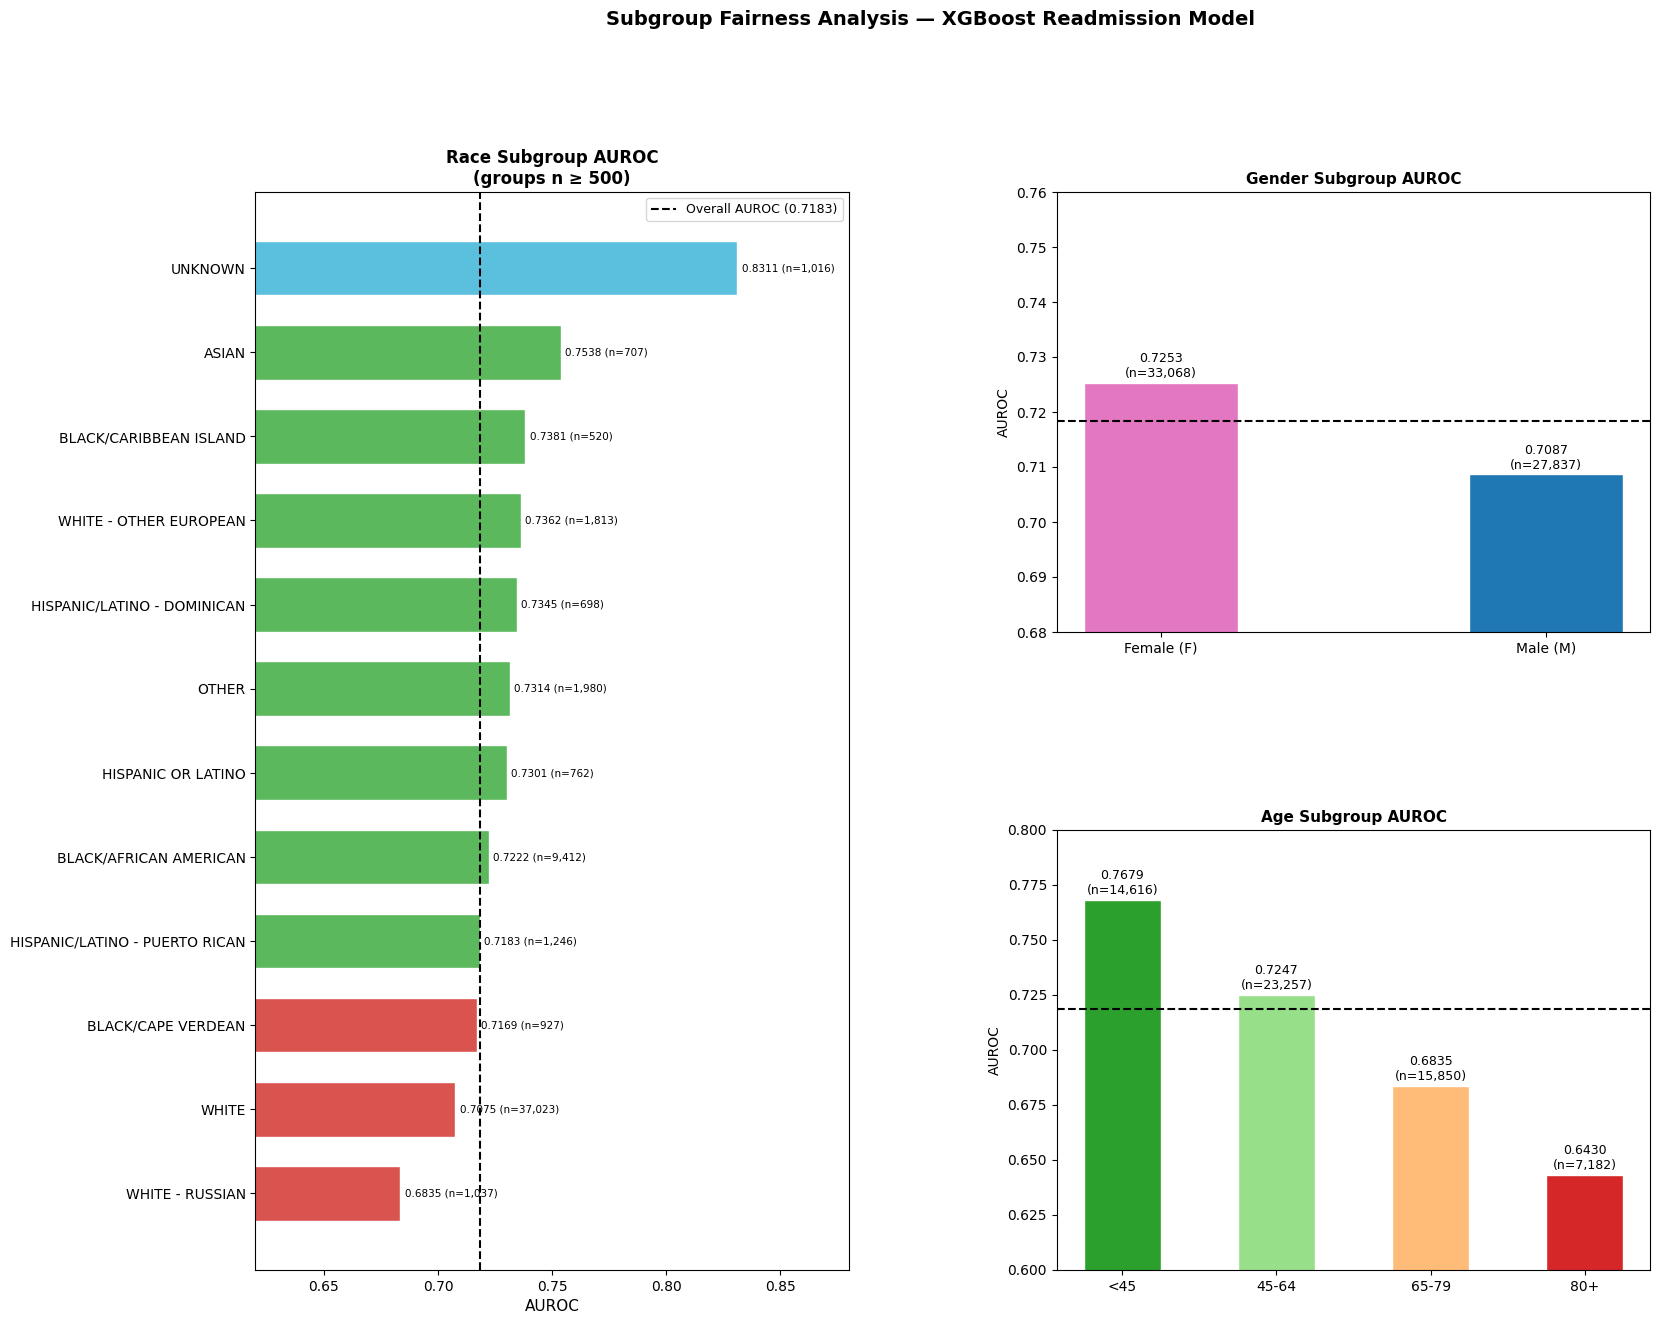

Saved: subgroup_fairness_analysis.png


In [14]:
# Cell 12 - Subgroup AUROC Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Race groups with n >= 500 only, sorted by AUROC
race_data = {
    'WHITE':                         {'auroc': 0.7075, 'n': 37023},
    'BLACK/AFRICAN AMERICAN':        {'auroc': 0.7222, 'n': 9412},
    'HISPANIC/LATINO - PUERTO RICAN':{'auroc': 0.7183, 'n': 1246},
    'OTHER':                         {'auroc': 0.7314, 'n': 1980},
    'WHITE - OTHER EUROPEAN':        {'auroc': 0.7362, 'n': 1813},
    'UNKNOWN':                       {'auroc': 0.8311, 'n': 1016},
    'WHITE - RUSSIAN':               {'auroc': 0.6835, 'n': 1037},
    'BLACK/CAPE VERDEAN':            {'auroc': 0.7169, 'n': 927},
    'HISPANIC/LATINO - DOMINICAN':   {'auroc': 0.7345, 'n': 698},
    'ASIAN':                         {'auroc': 0.7538, 'n': 707},
    'HISPANIC OR LATINO':            {'auroc': 0.7301, 'n': 762},
    'BLACK/CARIBBEAN ISLAND':        {'auroc': 0.7381, 'n': 520},
}

race_labels  = list(race_data.keys())
race_aurocs  = [race_data[k]['auroc'] for k in race_labels]
race_ns      = [race_data[k]['n'] for k in race_labels]

sorted_idx   = np.argsort(race_aurocs)
race_labels  = [race_labels[i] for i in sorted_idx]
race_aurocs  = [race_aurocs[i] for i in sorted_idx]
race_ns      = [race_ns[i]     for i in sorted_idx]

# Gender
gender_labels = ['Female (F)', 'Male (M)']
gender_aurocs = [0.7253, 0.7087]
gender_ns     = [33068, 27837]

# Age
age_labels = ['<45', '45-64', '65-79', '80+']
age_aurocs = [0.7679, 0.7247, 0.6835, 0.6430]
age_ns     = [14616, 23257, 15850, 7182]

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

overall_auroc = 0.7183
bar_colors = ['#d9534f' if a < overall_auroc else '#5bc0de' if a == max(race_aurocs) else '#5cb85c'
              for a in race_aurocs]

bars = ax1.barh(race_labels, race_aurocs, color=bar_colors, edgecolor='white', height=0.65)
ax1.axvline(x=overall_auroc, color='black', linestyle='--', linewidth=1.5, label=f'Overall AUROC ({overall_auroc})')
ax1.set_xlabel('AUROC', fontsize=11)
ax1.set_title('Race Subgroup AUROC\n(groups n ≥ 500)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim(0.62, 0.88)
for bar, auroc, n in zip(bars, race_aurocs, race_ns):
    ax1.text(auroc + 0.002, bar.get_y() + bar.get_height()/2,
             f'{auroc:.4f} (n={n:,})', va='center', fontsize=7.5)

ax2.bar(gender_labels, gender_aurocs, color=['#e377c2', '#1f77b4'], edgecolor='white', width=0.4)
ax2.axhline(y=overall_auroc, color='black', linestyle='--', linewidth=1.5)
ax2.set_ylabel('AUROC', fontsize=10)
ax2.set_title('Gender Subgroup AUROC', fontsize=11, fontweight='bold')
ax2.set_ylim(0.68, 0.76)
for i, (auroc, n) in enumerate(zip(gender_aurocs, gender_ns)):
    ax2.text(i, auroc + 0.001, f'{auroc:.4f}\n(n={n:,})', ha='center', fontsize=9)

ax3.bar(age_labels, age_aurocs, color=['#2ca02c','#98df8a','#ffbb78','#d62728'], edgecolor='white', width=0.5)
ax3.axhline(y=overall_auroc, color='black', linestyle='--', linewidth=1.5)
ax3.set_ylabel('AUROC', fontsize=10)
ax3.set_title('Age Subgroup AUROC', fontsize=11, fontweight='bold')
ax3.set_ylim(0.60, 0.80)
for i, (auroc, n) in enumerate(zip(age_aurocs, age_ns)):
    ax3.text(i, auroc + 0.003, f'{auroc:.4f}\n(n={n:,})', ha='center', fontsize=9)

fig.suptitle('Subgroup Fairness Analysis — XGBoost Readmission Model', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/content/subgroup_fairness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: subgroup_fairness_analysis.png")

In [16]:
# Cell 13 - Train XGBoost for 30d, 60d and 90d targets
import xgboost as xgb
import shap
from sklearn.metrics import roc_auc_score

targets = {
    '30d': 'readmitted_30d',
    '60d': 'readmitted_60d',
    '90d': 'readmitted_90d'
}

models         = {}
shap_values_all = {}
aurocs         = {}

for name, target in targets.items():
    print(f"Training for {name}...")

    y_train_t = df_sorted[target].iloc[:train_end]
    y_test_t  = df_sorted[target].iloc[val_end:]

    scale_pos_weight = (y_train_t == 0).sum() / (y_train_t == 1).sum()

    model = xgb.XGBClassifier(
        subsample=0.8, reg_lambda=2, reg_alpha=0.1,
        n_estimators=500, min_child_weight=5, max_depth=5,
        learning_rate=0.05, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42, eval_metric='auc', verbosity=0, tree_method='hist'
    )
    model.fit(X_train, y_train_t)

    y_pred  = model.predict_proba(X_test)[:, 1]
    auroc   = roc_auc_score(y_test_t, y_pred)
    aurocs[name]  = auroc
    models[name]  = model
    print(f"  {name} AUROC: {auroc:.4f}")

    explainer_t          = shap.TreeExplainer(model)
    shap_values_all[name] = explainer_t.shap_values(X_shap)

print("\nSummary:")
for name, auroc in aurocs.items():
    print(f"  {name}: {auroc:.4f}")

Training for 30d...
  30d AUROC: 0.7183
Training for 60d...
  60d AUROC: 0.7339
Training for 90d...
  90d AUROC: 0.7431

Summary:
  30d: 0.7183
  60d: 0.7339
  90d: 0.7431


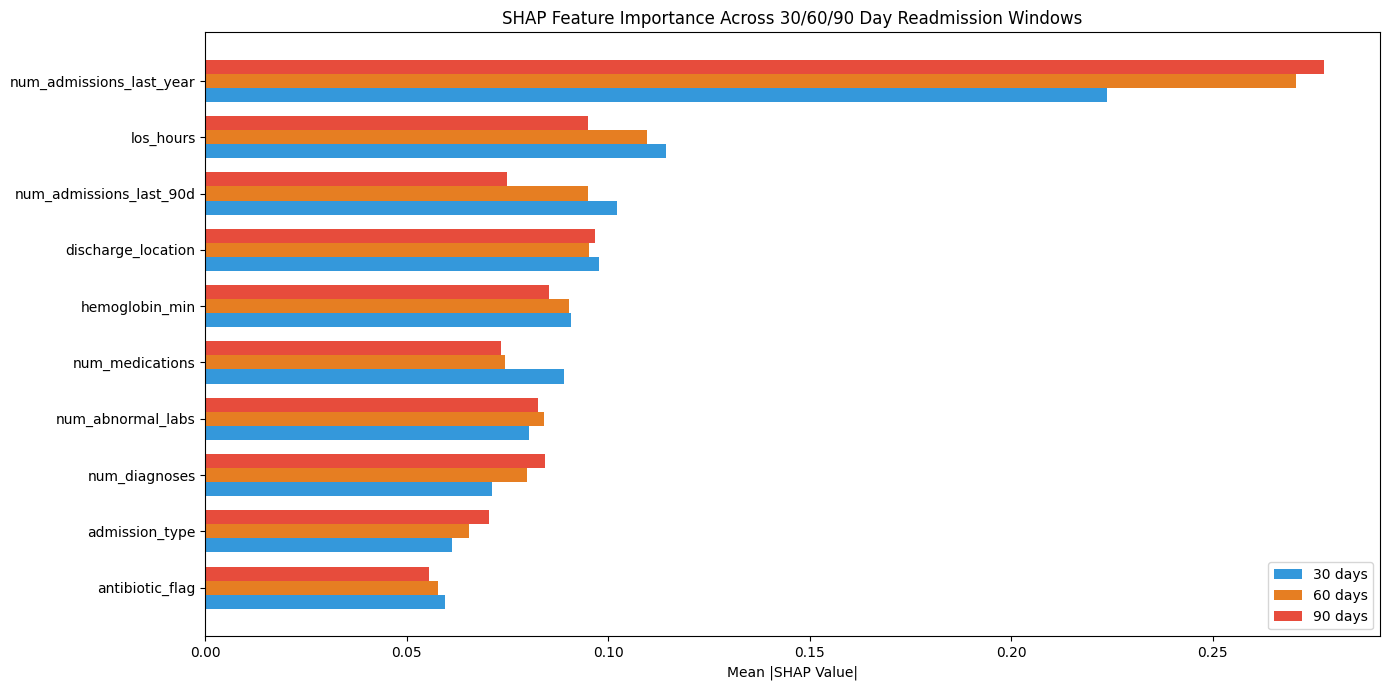

Saved: shap_window_comparison.png


In [17]:
# Cell 14 - 30/60/90 day SHAP feature importance comparison
import numpy as np
import matplotlib.pyplot as plt

# Mean absolute SHAP values per feature per target
mean_shap = {}
for name in ['30d', '60d', '90d']:
    mean_shap[name] = np.abs(shap_values_all[name]).mean(axis=0)

# Top 10 features by 30d importance
top10_idx = np.argsort(mean_shap['30d'])[-10:]
top10_names = [feature_cols[i] for i in top10_idx]

x = np.arange(len(top10_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(x - width, mean_shap['30d'][top10_idx], width, label='30 days', color='#3498db')
ax.barh(x, mean_shap['60d'][top10_idx], width, label='60 days', color='#e67e22')
ax.barh(x + width, mean_shap['90d'][top10_idx], width, label='90 days', color='#e74c3c')

ax.set_yticks(x)
ax.set_yticklabels(top10_names)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Feature Importance Across 30/60/90 Day Readmission Windows')
ax.legend()
plt.tight_layout()
plt.savefig('/content/shap_window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_window_comparison.png")

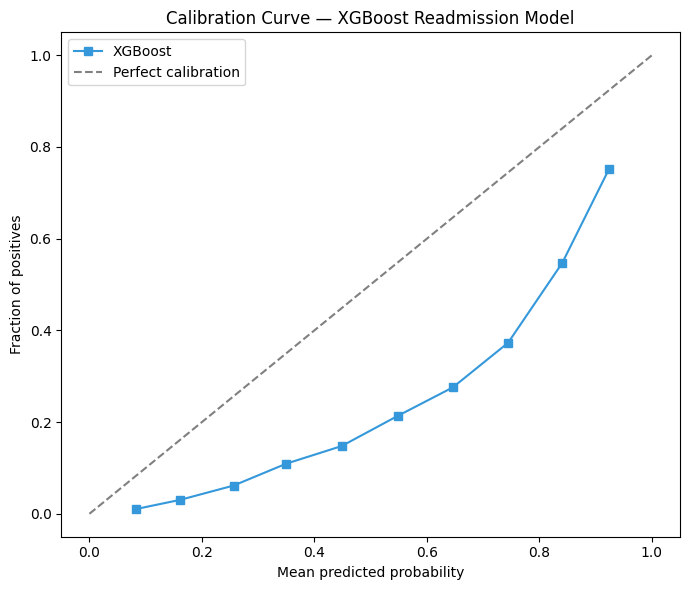

Mean predicted prob range: 0.0831 – 0.9234
Actual fraction pos range: 0.0104 – 0.7510
Base readmission rate: 0.1800


In [18]:
# Cell 15: Calibration Curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_pred_test = xgb_model.predict_proba(X_test)[:, 1]
fraction_pos, mean_pred = calibration_curve(y_test, y_pred_test, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred, fraction_pos, 's-', color='#3498db', label='XGBoost')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — XGBoost Readmission Model')
ax.legend()
plt.tight_layout()
plt.savefig('/content/calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean predicted prob range: {mean_pred.min():.4f} – {mean_pred.max():.4f}")
print(f"Actual fraction pos range: {fraction_pos.min():.4f} – {fraction_pos.max():.4f}")
print(f"Base readmission rate: {y_test.mean():.4f}")

In [20]:
#Cell 16: UNKNOWN Distributional Evidence
import pickle
import pandas as pd

le_mappings  = pickle.load(open('/content/final_le_mappings.pkl', 'rb'))
race_map     = le_mappings['race']['label_to_int']
marital_map  = le_mappings['marital_status']['label_to_int']

unknown_race_int    = race_map.get('UNKNOWN', None)
unknown_marital_int = marital_map.get('UNKNOWN', None)

print("UNKNOWN Subgroup Distributional Analysis")
print("=" * 50)

if unknown_race_int is not None:
    mask = X_test['race'] == unknown_race_int
    y_unknown = y_test[mask]
    y_pred_unknown = xgb_model.predict_proba(X_test[mask])[:, 1]
    from sklearn.metrics import roc_auc_score
    print(f"\nrace=UNKNOWN:")
    print(f"  N:                {mask.sum():,}")
    print(f"  Readmission rate: {y_unknown.mean()*100:.1f}%")
    print(f"  AUROC:            {roc_auc_score(y_unknown, y_pred_unknown):.4f}")
    print(f"  Mean predicted:   {y_pred_unknown.mean():.4f}")

overall_readm = y_test.mean()
print(f"\nOverall test readmission rate: {overall_readm*100:.1f}%")
print(f"UNKNOWN is {overall_readm / y_unknown.mean():.1f}x lower risk than overall population")

if unknown_marital_int is not None:
    mask_m = X_test['marital_status'] == unknown_marital_int
    y_marital = y_test[mask_m]
    print(f"\nmarital_status=UNKNOWN:")
    print(f"  N:                {mask_m.sum():,}")
    print(f"  Readmission rate: {y_marital.mean()*100:.1f}%")

print("\nConclusion: UNKNOWN demographic categories reflect genuinely")
print("lower-risk patient profiles in MIMIC-IV, not random missingness.")
print("Model learned a real statistical pattern — clinically non-actionable.")

UNKNOWN Subgroup Distributional Analysis

race=UNKNOWN:
  N:                1,016
  Readmission rate: 5.0%
  AUROC:            0.8311
  Mean predicted:   0.2190

Overall test readmission rate: 18.0%
UNKNOWN is 3.6x lower risk than overall population

marital_status=UNKNOWN:
  N:                874
  Readmission rate: 5.1%

Conclusion: UNKNOWN demographic categories reflect genuinely
lower-risk patient profiles in MIMIC-IV, not random missingness.
Model learned a real statistical pattern — clinically non-actionable.


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Calibrated AUROC: 0.7179 (original: 0.7183)


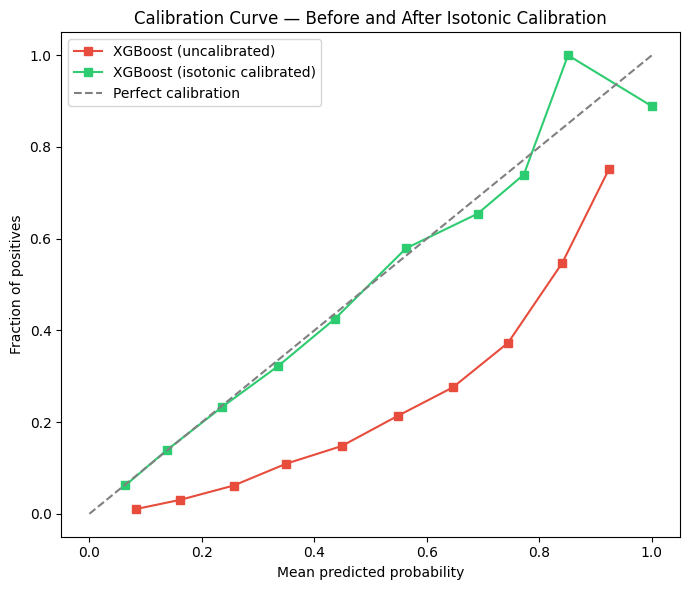

Saved: xgboost_calibrated.pkl


In [19]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

calibrated_model = CalibratedClassifierCV(xgb_model, method='isotonic', cv='prefit')
calibrated_model.fit(X_val, y_val)

y_pred_cal = calibrated_model.predict_proba(X_test)[:, 1]

frac_pos_raw, mean_pred_raw = calibration_curve(y_test, xgb_model.predict_proba(X_test)[:, 1], n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_pred_cal, n_bins=10)

from sklearn.metrics import roc_auc_score
auroc_cal = roc_auc_score(y_test, y_pred_cal)
print(f"Calibrated AUROC: {auroc_cal:.4f} (original: 0.7183)")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred_raw, frac_pos_raw, 's-', color='#e74c3c', label='XGBoost (uncalibrated)')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', color='#2ecc71', label='XGBoost (isotonic calibrated)')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — Before and After Isotonic Calibration')
ax.legend()
plt.tight_layout()
plt.savefig('/content/calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

import pickle
pickle.dump(calibrated_model, open('/content/xgboost_calibrated.pkl', 'wb'))
print("Saved: xgboost_calibrated.pkl")

# NB07 — Conclusions & Key Takeaways

- XGBoost with 45 features on a chronological 70/15/15 split gives a test AUROC of 0.7183. The model ranks patients correctly more than 70% of the time, which for a 30-day readmission task on a dataset this heterogeneous, is defensible.

- SHAP confirms what clinical intuition would expect — prior admission history dominates, followed by length of stay and lab abnormalities. Demographics sit lower in global importance, but the low-risk waterfall tells a different story: race and marital status UNKNOWN push predictions down significantly at the local level. That gap between global and local behaviour is the whole point of this thesis.

- The calibration analysis exposed something important — the model is overconfident. Raw predicted probabilities cannot be handed to a clinician as-is. Isotonic calibration fixes most of it with essentially zero AUROC loss (0.7179 vs 0.7183), so the calibrated model is what should be used in any clinical-facing output.

- UNKNOWN subgroup analysis confirmed this is not a preprocessing mistake. Race=UNKNOWN patients have a 5.0% readmission rate vs 18.0% overall — 3.6x lower risk. The model learned a real distributional pattern. The problem is not that it is wrong, the problem is that it is not actionable. A clinician cannot do anything with "race is unknown." That is exactly the failure mode a clinical XAI validation framework needs to catch, and this notebook documents it precisely.

- Subgroup fairness shows degradation with age — AUROC drops from 0.7679 for under-45 to 0.6430 for 80+. The model is weakest exactly where clinical decisions are most complex. That is worth flagging in the thesis discussion, not hiding.